# F1 Team Classifier — On-the-Fly Cropping

## Goal

Build a four-team F1 car classifier using the Roboflow COCO annotations. Each annotated car is cropped **in memory** when a batch is loaded; no duplicate cropped image files are created.

Classes: **Ferrari, Mclaren, Mercedes, Redbull**.

## Setup

This notebook uses transfer learning with a pretrained ResNet18 CNN. It freezes the pretrained feature extractor and trains a new four-class output layer first, making the baseline faster and less data-hungry than training a CNN from scratch.

The original Roboflow `train`, `valid`, and `test` splits are preserved.

In [ ]:
import json
import math
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "roboflow_f1"
TEAM_NAMES = ["Ferrari", "Mclaren", "Mercedes", "Redbull"]
IMAGE_SIZE = 320
BATCH_SIZE = 32
PADDING_RATIO = 0.08

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_ROOT}")

print(f"Project: {PROJECT_ROOT}")
print(f"Dataset: {DATASET_ROOT}")

Project: /Users/gianmiranda/Programming/Projects Personales/F1-Comp-Vision
Dataset: /Users/gianmiranda/Programming/Projects Personales/F1-Comp-Vision/data/raw/roboflow_f1


## Data

`CocoCarCropDataset` creates one classification example per team-labeled bounding box. In `__getitem__`, it opens the original image, adds a small amount of padding around the box, crops the car in memory, applies transforms, and returns the tensor with its team label.

In [16]:
class CocoCarCropDataset(Dataset):
    def __init__(
        self,
        split_directory,
        team_names,
        transform=None,
        padding_ratio=0.08,
    ):
        self.split_directory = Path(split_directory)
        self.team_names = list(team_names)
        self.class_to_index = {
            team_name: index
            for index, team_name in enumerate(self.team_names)
        }
        self.transform = transform
        self.padding_ratio = padding_ratio

        annotation_path = self.split_directory / "_annotations.coco.json"
        with annotation_path.open() as file:
            coco = json.load(file)

        images_by_id = {
            image["id"]: image
            for image in coco["images"]
        }
        categories_by_id = {
            category["id"]: category["name"]
            for category in coco["categories"]
        }

        self.samples = []
        for annotation in coco["annotations"]:
            team_name = categories_by_id[annotation["category_id"]]
            if team_name not in self.class_to_index:
                continue

            x, y, width, height = annotation["bbox"]
            if width <= 0 or height <= 0:
                continue

            image_info = images_by_id[annotation["image_id"]]
            self.samples.append(
                {
                    "image_path": self.split_directory / image_info["file_name"],
                    "bbox": (x, y, width, height),
                    "team_name": team_name,
                    "label": self.class_to_index[team_name],
                }
            )

    def __len__(self):
        return len(self.samples)

    def _crop_with_padding(self, image, bbox):
        x, y, width, height = bbox
        horizontal_padding = width * self.padding_ratio
        vertical_padding = height * self.padding_ratio

        left = max(0, math.floor(x - horizontal_padding))
        top = max(0, math.floor(y - vertical_padding))
        right = min(image.width, math.ceil(x + width + horizontal_padding))
        bottom = min(image.height, math.ceil(y + height + vertical_padding))

        return image.crop((left, top, right, bottom))

    def __getitem__(self, index):
        sample = self.samples[index]

        with Image.open(sample["image_path"]) as image:
            image = image.convert("RGB")
            crop = self._crop_with_padding(image, sample["bbox"])

        if self.transform is not None:
            crop = self.transform(crop)

        return crop, sample["label"]

In [17]:
imagenet_mean = [0.485, 0.456, 0.406] #this is the mean for ImageNet dataset, used for normalization
imagenet_std = [0.229, 0.224, 0.225] #this is the standard deviation for ImageNet dataset, used for normalization

train_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

train_dataset = CocoCarCropDataset(
    DATASET_ROOT / "train",
    TEAM_NAMES,
    transform=train_transform,
    padding_ratio=PADDING_RATIO,
)
valid_dataset = CocoCarCropDataset(
    DATASET_ROOT / "valid",
    TEAM_NAMES,
    transform=evaluation_transform,
    padding_ratio=PADDING_RATIO,
)
test_dataset = CocoCarCropDataset(
    DATASET_ROOT / "test",
    TEAM_NAMES,
    transform=evaluation_transform,
    padding_ratio=PADDING_RATIO,
)
#num_workers what it does is to specify the number of subprocesses to use for data loading. If num_workers is set to 0, the data loading will be done in the main process. If it is set to a positive integer, that number of subprocesses will be used to load the data in parallel, which can speed up data loading, especially for large datasets. However, using multiple workers can also introduce complexity and potential issues, such as increased memory usage or difficulties with debugging.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0) 
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

for split_name, dataset in [
    ("train", train_dataset),
    ("valid", valid_dataset),
    ("test", test_dataset),
]:
    counts = Counter(sample["team_name"] for sample in dataset.samples)
    print(f"{split_name}: {len(dataset):,} crops | {dict(counts)}")

train: 6,997 crops | {'Ferrari': 1590, 'Mercedes': 2169, 'Redbull': 1538, 'Mclaren': 1700}
valid: 660 crops | {'Mclaren': 147, 'Redbull': 146, 'Mercedes': 213, 'Ferrari': 154}
test: 338 crops | {'Mercedes': 105, 'Ferrari': 84, 'Redbull': 79, 'Mclaren': 70}


## Checks

The next cell previews crops produced by the same dataset code that training will use. Re-run it to inspect a new random sample. Training augmentations can make brightness and color look slightly different by design.

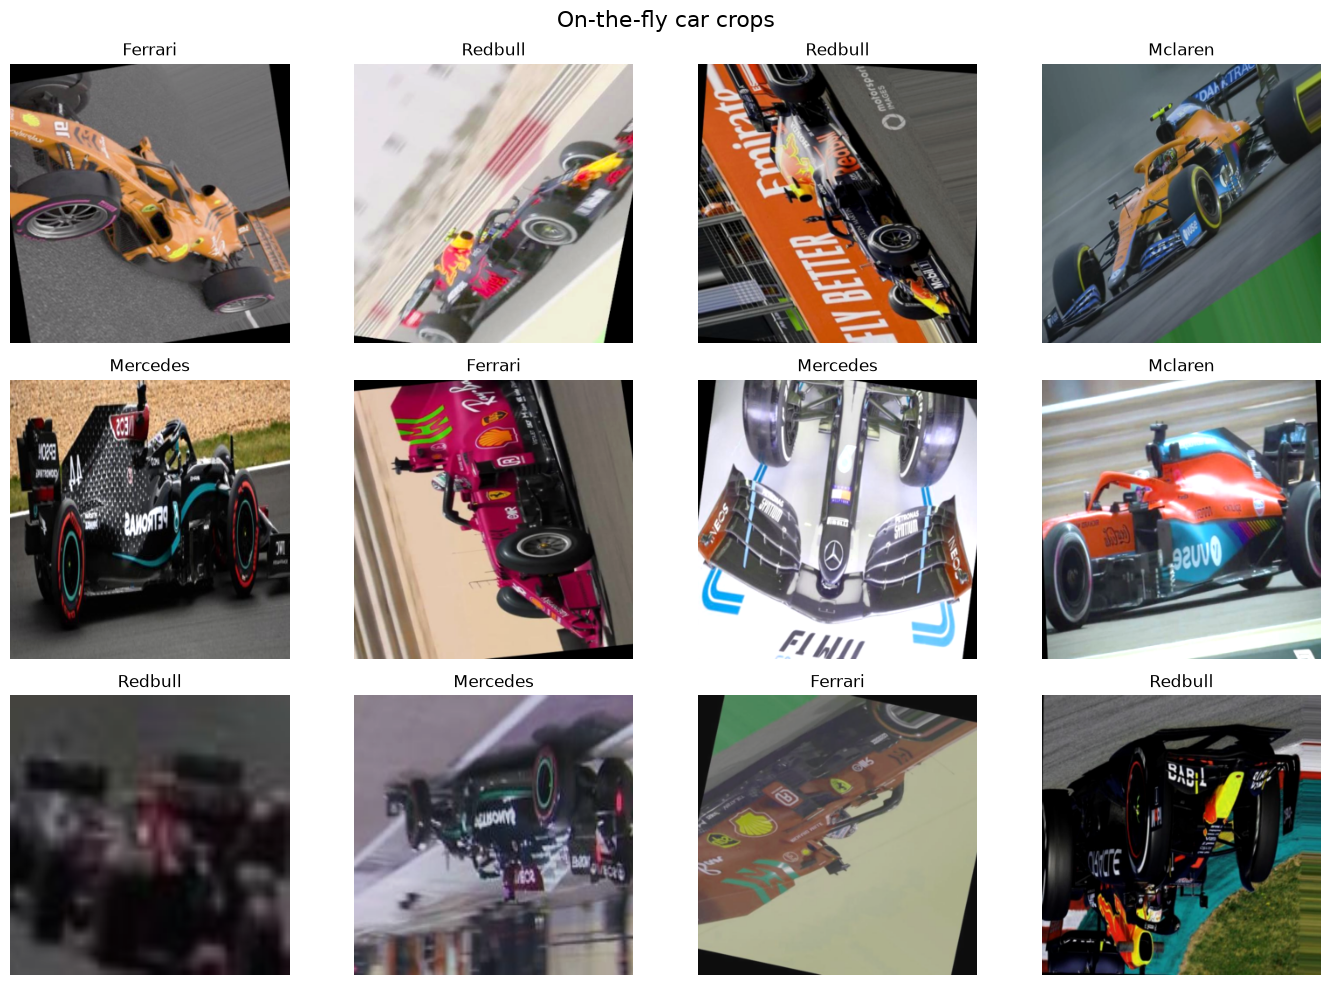

In [18]:
def denormalize(image_tensor):
    mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    std = torch.tensor(imagenet_std).view(3, 1, 1)
    return (image_tensor.cpu() * std + mean).clamp(0, 1)

sample_indices = random.sample(range(len(train_dataset)), 12)
figure, axes = plt.subplots(3, 4, figsize=(14, 10))

for axis, sample_index in zip(axes.flatten(), sample_indices):
    image_tensor, label = train_dataset[sample_index]
    axis.imshow(denormalize(image_tensor).permute(1, 2, 0))
    axis.set_title(TEAM_NAMES[label])
    axis.axis("off")

plt.suptitle("On-the-fly car crops", fontsize=16)
plt.tight_layout()
plt.show()

## CNN baseline

In [19]:

class F1_CNN(nn.Module):
    def __init__(self, number_of_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, number_of_classes),
        )

    def forward(self, images):
        features = self.features(images)
        return self.classifier(features)


model = F1_CNN(number_of_classes=len(TEAM_NAMES)).to(DEVICE)

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)
    

## Training

Set `RUN_TRAINING = True` when you are ready. Five epochs trains only the new classification layer and is a sensible first baseline. Keep the computer awake while it runs.

In [20]:
def run_epoch(model, data_loader, loss_function, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    progress = tqdm(data_loader, leave=False) #this is a progress bar that shows the progress of the epoch, it is useful for long epochs, and it is set to leave=False so that it does not leave a new line after the progress bar is done
    
    for images, labels in progress:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            outputs = model(images)
            loss = loss_function(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = outputs.argmax(dim=1)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (predictions == labels).sum().item()
        total_examples += batch_size

        progress.set_postfix(loss=f"{loss.item():.3f}")

    return total_loss / total_examples, total_correct / total_examples


def evaluate_model(model, data_loader, loss_function):
    model.eval()

    total_loss = 0.0
    total_examples = 0
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, leave=False):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = loss_function(outputs, labels)
            predictions = outputs.argmax(dim=1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_examples += batch_size
            true_labels.extend(labels.cpu().tolist())
            predicted_labels.extend(predictions.cpu().tolist())

    correct_predictions = sum(
        true_label == predicted_label
        for true_label, predicted_label in zip(true_labels, predicted_labels)
    )

    return {
        "loss": total_loss / total_examples,
        "accuracy": accuracy_score(true_labels, predicted_labels),
        "precision": precision_score(
            true_labels, predicted_labels, average="macro", zero_division=0
        ),
        "recall": recall_score(
            true_labels, predicted_labels, average="macro", zero_division=0
        ),
        "f1_score": f1_score(
            true_labels, predicted_labels, average="macro", zero_division=0
        ),
        "correct_predictions": correct_predictions,
        "total_examples": total_examples,
    }


def display_test_results(results):
    metric_rows = [
        (
            "Accuracy",
            f"{results['accuracy']:.2%}",
            "Share of all test crops predicted correctly.",
        ),
        (
            "Precision",
            f"{results['precision']:.2%}",
            "When a team is predicted, how often it is correct (macro average).",
        ),
        (
            "Recall",
            f"{results['recall']:.2%}",
            "How many real cars from each team are found (macro average).",
        ),
        (
            "F1-score",
            f"{results['f1_score']:.2%}",
            "Balance between precision and recall (macro average).",
        ),
        (
            "Loss",
            f"{results['loss']:.4f}",
            "Confidence-weighted error; this is not a percentage.",
        ),
    ]

    print("\n" + "=" * 88)
    print("TEST RESULTS — CUSTOM CNN")
    print("=" * 88)
    print(
        f"Overall: {results['correct_predictions']:,} of "
        f"{results['total_examples']:,} test crops were classified correctly "
        f"({results['accuracy']:.2%})."
    )
    print("-" * 88)
    print(f"{'Metric':<12} {'Score':>10}  What the number represents")
    print("-" * 88)
    for metric_name, score, meaning in metric_rows:
        print(f"{metric_name:<12} {score:>10}  {meaning}")
    print("-" * 88)
    print("Accuracy, precision, recall, and F1: higher is better; 100% is perfect.")
    print("Loss: lower is better; 0 is perfect. Compare loss only with similar models/data.")
    print("Macro average: Ferrari, McLaren, Mercedes, and Red Bull count equally.")
    print("=" * 88)


def train_model(model, epochs):
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = run_epoch(
            model,
            train_loader,
            loss_function,
            optimizer,
        )
        valid_loss, valid_accuracy = run_epoch(
            model,
            valid_loader,
            loss_function,
        )

        result = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "valid_loss": valid_loss,
            "valid_accuracy": valid_accuracy,
        }
        history.append(result)

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_loss:.4f}, accuracy {train_accuracy:.1%} | "
            f"valid loss {valid_loss:.4f}, accuracy {valid_accuracy:.1%}"
        )

    return history

In [ ]:
RUN_TRAINING = True
EPOCHS = 10

if RUN_TRAINING:
    history = train_model(model, EPOCHS)
    test_results = evaluate_model(model, test_loader, loss_function)
    display_test_results(test_results)

    artifacts_directory = PROJECT_ROOT / "artifacts"
    artifacts_directory.mkdir(exist_ok=True)
    model_path = artifacts_directory / "f1_team_custom_cnn.pt"

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": TEAM_NAMES,
            "image_size": IMAGE_SIZE,
        },
        model_path,
    )
    print(f"Saved model: {model_path}")
else:
    print("Baseline is ready. Set RUN_TRAINING = True to begin training.")

  0%|          | 0/219 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

Epoch 01 | train loss 0.9730, accuracy 59.6% | valid loss 0.6501, accuracy 79.1%


  0%|          | 0/219 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

...

  0%|          | 0/219 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

Epoch 10 | train loss 0.3257, accuracy 89.8% | valid loss 0.3197, accuracy 92.9%


  0%|          | 0/11 [00:00<?, ?it/s]


TEST RESULTS — CUSTOM CNN
Overall: 319 of 338 test crops were classified correctly (94.38%).
----------------------------------------------------------------------------------------
Metric            Score  What the number represents
----------------------------------------------------------------------------------------
Accuracy         94.38%  Share of all test crops predicted correctly.
Precision        94.17%  When a team is predicted, how often it is correct (macro average).
Recall           94.03%  How many real cars from each team are found (macro average).
F1-score         94.10%  Balance between precision and recall (macro average).
Loss             0.2041  Confidence-weighted error; this is not a percentage.
----------------------------------------------------------------------------------------
Accuracy, precision, recall, and F1: higher is better; 100% is perfect.
Loss: lower is better; 0 is perfect. Compare loss only with similar models/data.
Macro average: Ferrari, McLar

## Understanding the test results

The evaluation cell above generates the current model's results directly from the test set.

- **Accuracy** — the percentage of all test crops classified correctly.
- **Precision** — when the model predicts a team, how often that prediction is correct.
- **Recall** — how many cars belonging to each team the model successfully finds.
- **F1-score** — a combined measure of precision and recall.
- **Loss** — the model's confidence-weighted error. It is **not** a percentage; lower is better.

Precision, recall, and F1 use a **macro average**, so all four teams contribute equally even when their test-set counts differ.

### Test Results 

| Configuration | Accuracy | Precision | Recall | F1-Score | Loss |
|---|---:|---:|---:|---:|---:|
| v1 | 90.53% | 91.30% | 90.01% | 89.87% | 0.2976 |
| v2 | 97.04% | 96.89% | 96.91% | 96.88% | 0.1851 |
| v3 | 94.38% | 94.17% | 94.03% | 94.10% | 0.2041 |

### Model Configurations

v2 increases training from 5 to 10 epochs. v3 keeps the v2 settings and increases the input image size from 224 x 224 to 320 x 320.

| Setting | v1 | v2 | v3 |
|---|---:|---:|---:|
| Model | Custom CNN | Custom CNN | Custom CNN |
| Convolution channels | 32, 64, 128, 256 | 32, 64, 128, 256 | 32, 64, 128, 256 |
| Input image size | 224 x 224 | 224 x 224 | **320 x 320** |
| Batch size | 32 | 32 | 32 |
| Optimizer | Adam | Adam | Adam |
| Learning rate | 0.001 | 0.001 | 0.001 |
| Loss function | Cross-entropy | Cross-entropy | Cross-entropy |
| Dropout | 0.3 | 0.3 | 0.3 |
| Crop padding ratio | 0.08 | 0.08 | 0.08 |
| Random seed | 42 | 42 | 42 |
| **Epochs** | **5** | **10** | **10** |

### Notes
The v1 version was the first version created, the v2 version only changed the epochs from 5-10 this change already put performed the v1 version and the example CNN. But this result makes sense since it had double more the training. To make things fair now ima test the example cnn with the same ammount of epochs.

After testing Example CNN with 10 epochs the results of it stayed the same. Even with more double the epochs. That was a little unexpected. 

The Reason: EfficientNet was pretrained and its feature layers were frozen, so only the small classifier trained and had mostly converged within five epochs. The custom CNN started from random weights and trained every layer, so it needed the additional epochs to keep learning useful features. Also, identical rounded metrics can occur even if the model’s confidence changed slightly.

For version v3 we changed the image size from 220 to 320 reason: may preserve more details such as logos, sponsor text, and livery patterns. 
Result was worse than v2 but better than v1


### Configuration and Hyperparameter Guide

These settings can be changed when testing new model versions. Change one major setting at a time so its effect can be measured clearly.

| Configuration | Current value | What happens when it changes | Main trade-off |
|---|---|---|---|
| Epochs | 10 | More epochs give the model more opportunities to learn; too many can cause overfitting. | Training time vs. generalization |
| Batch size | 32 | Larger batches train faster and more smoothly but use more memory; smaller batches are noisier and may generalize better. | Memory and speed vs. gradient noise |
| Learning rate | 0.001 | A higher value learns faster but can skip the best solution; a lower value is steadier but slower. | Speed vs. stability |
| Optimizer | Adam | Different optimizers update weights differently and may converge faster, slower, or to a different solution. | Convergence behavior |
| Loss function | Cross-entropy | Changing the loss changes what errors the model is penalized for; class-weighted loss can help imbalanced classes. | Objective and class balance |
| Image size | 224 x 224 | Larger images preserve more detail but require more memory and computation; smaller images train faster but lose detail. | Detail vs. cost |
| Convolution channels | 32, 64, 128, 256 | More channels increase model capacity; fewer channels make the model smaller and faster. | Accuracy potential vs. memory and overfitting |
| Number of convolution layers | 4 | More layers can learn more complex features but are slower and easier to overfit. | Feature complexity vs. training difficulty |
| Kernel size | 3 x 3 | Larger kernels see a wider area at once but add parameters and computation. | Wider context vs. efficiency |
| Dropout | 0.3 | More dropout increases regularization but can cause underfitting; less dropout can improve fit but increase overfitting. | Regularization vs. learning capacity |
| Crop padding ratio | 0.08 | More padding includes additional car context; less padding focuses more tightly on the car. | Context vs. background noise |
| Horizontal-flip probability | 0.5 | More flipping adds variety and can improve generalization when orientation is not important. | Robustness vs. unrealistic samples |
| Color jitter | Brightness 0.15, contrast 0.15, saturation 0.10 | Stronger jitter improves resistance to lighting changes but can distort team colors. | Robustness vs. color accuracy |
| Weight decay | Not currently used | Adding it discourages very large weights and can reduce overfitting. | Regularization vs. underfitting |
| Pretrained weights | Used by Example CNN | Pretraining usually learns faster and needs less data; training from scratch gives full control but needs more epochs and data. | Fast transfer learning vs. full specialization |
| Frozen layers | EfficientNet feature extractor frozen | Unfreezing layers lets pretrained features adapt to F1 cars but requires a smaller learning rate and more computation. | Adaptability vs. overfitting risk |
| Random seed | 42 | A different seed changes initialization, shuffle order, and augmentations, so results may vary slightly. | Reproducibility; not a direct quality control |
| Shuffle training data | True | Shuffling prevents the model from learning the dataset order; disabling it can produce biased updates. | Usually keep enabled |
| Data-loader workers | 0 | More workers can load data faster but use more memory and may be less stable on some systems. | Loading speed vs. system resources |
| Device | MPS, CUDA, or CPU | A GPU or Apple MPS speeds up training; the CPU is slower but should produce similar results. | Training speed |
| Learning-rate scheduler | Not currently used | A scheduler lowers the learning rate during training, which can help the model settle into a better solution. | Extra tuning complexity vs. finer convergence |
| Early stopping | Not currently used | Stops training when validation performance no longer improves, saving time and limiting overfitting. | Efficiency vs. stopping too early |